## 1: Project Title: Tesla Stock Price Prediction using SimpleRNN and LSTM

## Developed & Deployed By: Dharminder Singh Virk

## 1.1: Project Type

Deep Learning Based Time Series Forecasting Project

Category:
- Data Science
- Machine Learning
- Deep Learning
- Financial Analytics

## 1.2: Project Summary

This project aims to predict Tesla stock closing prices using Deep Learning models such as SimpleRNN and LSTM.

Historical Tesla stock market data was collected and preprocessed before training the models.

The stock prices were scaled using MinMaxScaler and converted into time-series sequences for forecasting.

Both SimpleRNN and LSTM models were trained and evaluated using Mean Squared Error (MSE).

Hyperparameter tuning was performed using Keras Tuner to optimize model performance.

Finally, a Streamlit web application was developed to visualize stock trends and generate future stock price predictions.

## 1.3: Problem Statement

Stock market prices are highly dynamic and influenced by multiple factors.

Investors and analysts often face challenges in predicting future stock prices accurately.

Traditional statistical methods may not effectively capture complex temporal patterns present in stock market data.

Therefore, there is a need for a Deep Learning-based solution that can learn historical trends and forecast future Tesla stock prices with improved accuracy.

## 1.4: Project Objectives

- Analyze historical Tesla stock market data.

- Perform data preprocessing and feature scaling.

- Build a SimpleRNN model for stock price prediction.

- Build an LSTM model for stock price prediction.

- Compare the performance of both models.

- Optimize the model using Hyperparameter Tuning.

- Predict future Tesla stock prices.

- Develop an interactive Streamlit web application for prediction and visualization.

Github Link:

## 1.5: Data Description

Dataset Name:
Tesla Stock Market Dataset (TSLA)

Total Records:
2416

Total Features:
7

Features:

1. Date
   Trading Date

2. Open
   Opening Stock Price

3. High
   Highest Stock Price

4. Low
   Lowest Stock Price

5. Close
   Closing Stock Price

6. Adj Close
   Adjusted Closing Price

7. Volume
   Number of Shares Traded

Target Variable:
Close Price

## 1.6: Domain

Primary Domain:
Finance

Sub-Domains:
- Stock Market Analytics
- Financial Forecasting
- Time Series Analysis
- Deep Learning
- Investment Analytics

## Github Link: https://github.com/dharmindersinghvirk25-creator/Tesla-Stock-Price-Prediction-using-SimpleRNN-and-LSTM

##1.7: Skills Used

Data Analysis Skills:
- Data Cleaning
- Data Preprocessing
- Feature Selection
- Data Scaling

Exploratory Data Analysis:
- Trend Analysis
- Correlation Analysis
- Data Visualization

Machine Learning Skills:
- Time Series Forecasting
- Model Evaluation

Deep Learning Skills:
- SimpleRNN
- LSTM
- Hyperparameter Tuning

Deployment Skills:
- Streamlit Application Development
- Model Deployment

##1.8: Tools and Technologies Used

Programming Language:
- Python

Development Environment:
- Google Colab

Data Processing Libraries:
- Pandas
- NumPy

Visualization Libraries:
- Matplotlib
- Seaborn

Machine Learning Libraries:
- Scikit-Learn

Deep Learning Frameworks:
- TensorFlow
- Keras

Hyperparameter Tuning:
- Keras Tuner

Web Application Framework:
- Streamlit

Deployment Tools:
- Ngrok
- Pyngrok

Version Control (Optional):
- Git
- GitHub

##1.9: Models Used

Model 1:
SimpleRNN

Model 2:
LSTM (Long Short-Term Memory)

Optimization Technique:
Random Search Hyperparameter Tuning using Keras Tuner

##1.10: Evaluation Metrics

Mean Squared Error (MSE)

Purpose:
To measure the prediction error between actual stock prices and predicted stock prices.

## 2: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

## 3: Load Dataset

In [2]:
df = pd.read_csv("TSLA.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### 3.1: Check Shape

In [3]:
df.shape

(2416, 7)

### 3.2: Check Datatype:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


### 3.3: Check Missing Values:

In [5]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


## 4: Data Cleaning
### 4.1: Missing Values Check:

In [6]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [7]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_36700/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## 5: Convert Date

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

## 6: EDA
### 6.1: Closing Price Trend

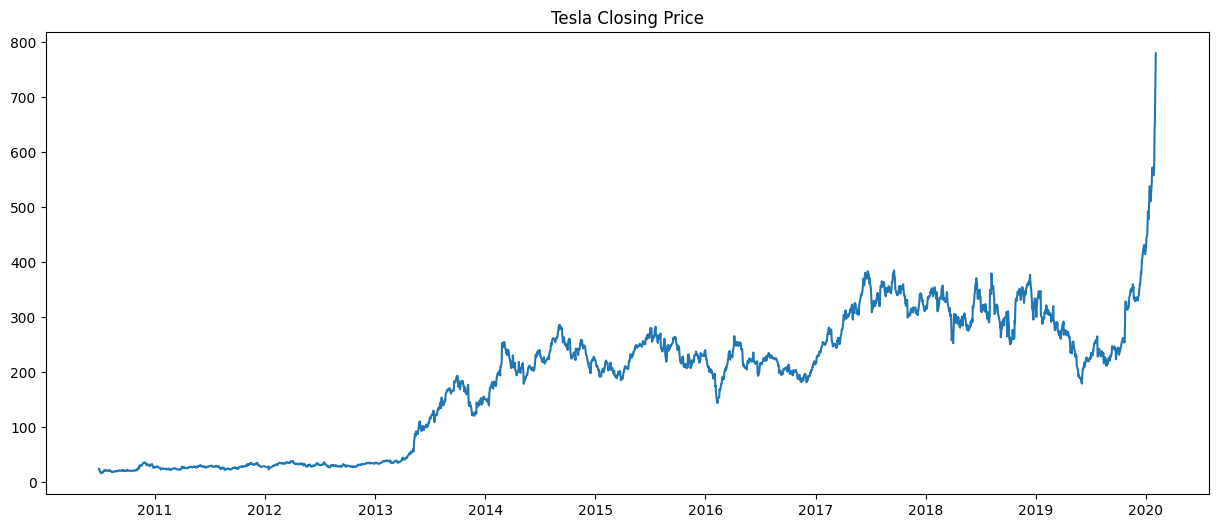

In [9]:
plt.figure(figsize=(15,6))
plt.plot(df['Close'])
plt.title("Tesla Closing Price")
plt.show()

### 6.2: Volume Analysis

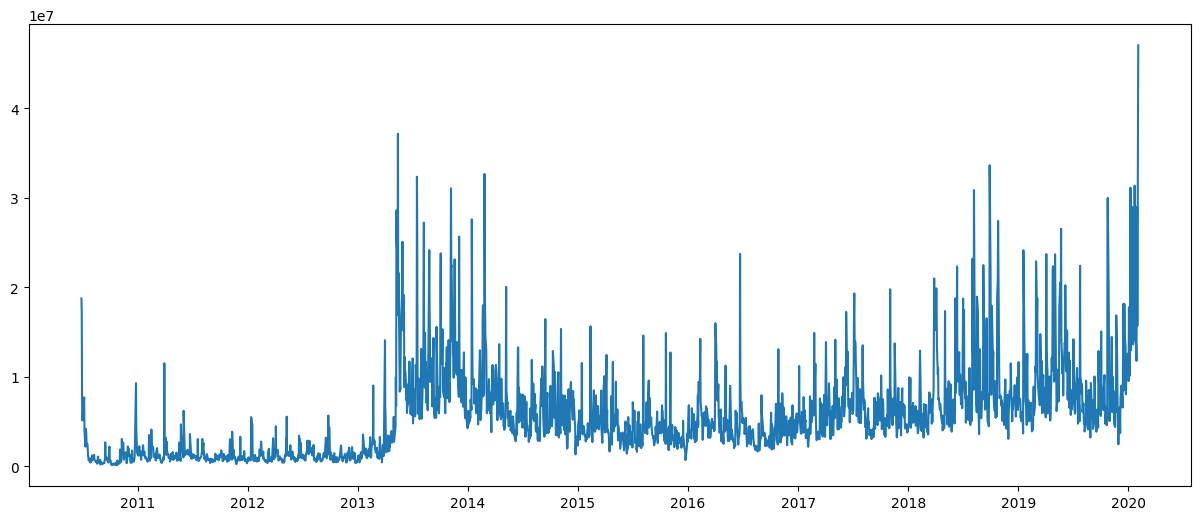

In [10]:
plt.figure(figsize=(15,6))
plt.plot(df['Volume'])
plt.show()

### 6.3: Correlation Heatmap

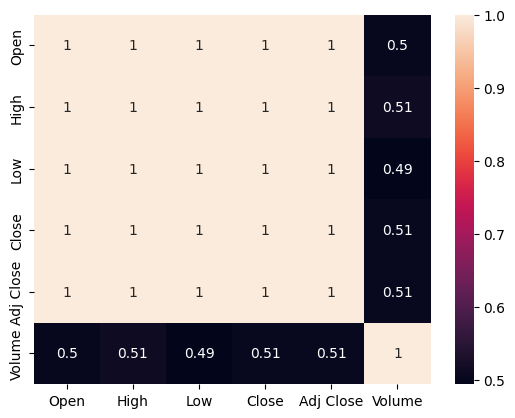

In [11]:
sns.heatmap(df.corr(),annot=True)
plt.show()

### 6.4: Distribution

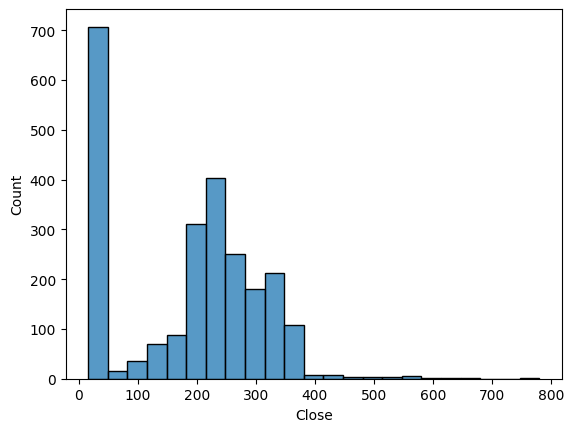

In [12]:
sns.histplot(df['Close'])
plt.show()

## 7: Feature Selection

### 7.1: Target:

In [13]:
close_price = df[['Close']]

## 8: Scaling

### 8.1: RNN and LSTM scaling

In [14]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(close_price)

## 9: Create Time Series Sequences

### 9.1: Window Size:

In [15]:
window = 60

### 60 previous days

### 9.2: Predict next day

### 9.2.1: Function:

In [16]:
X=[]
y=[]

for i in range(window,len(scaled_data)):
    X.append(scaled_data[i-window:i,0])
    y.append(scaled_data[i,0])

X=np.array(X)
y=np.array(y)

### 9.3: Reshape:

In [17]:
X=X.reshape(X.shape[0],X.shape[1],1)

### 10: Train Test Split

In [18]:
train_size=int(len(X)*0.8)

X_train=X[:train_size]
X_test=X[train_size:]

y_train=y[:train_size]
y_test=y[train_size:]

## 11: Build SimpleRNN Model

In [19]:
model_rnn=Sequential()

model_rnn.add(
SimpleRNN(
50,
return_sequences=False,
input_shape=(X_train.shape[1],1)
))

model_rnn.add(Dropout(0.2))

model_rnn.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 11.1: Compile

In [20]:
model_rnn.compile(
optimizer='adam',
loss='mse'
)

### 11.2: Train

In [21]:
early_stop=EarlyStopping(
patience=10,
restore_best_weights=True
)

history_rnn=model_rnn.fit(
X_train,
y_train,
epochs=50,
batch_size=32,
validation_data=(X_test,y_test),
callbacks=[early_stop]
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0046 - val_loss: 8.4720e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1666e-04 - val_loss: 6.1435e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.1811e-04 - val_loss: 6.9611e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.2275e-04 - val_loss: 4.9117e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.8781e-04 - val_loss: 5.6403e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.5320e-04 - val_loss: 6.0422e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.8297e-04 - val_loss: 6.3845e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5471e-04 - val_loss: 4.4794e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6319e-04 - val_loss: 4.3688e-04
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.2365e-04 - val_loss

## 12: RNN Prediction

In [22]:
rnn_pred=model_rnn.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


### 12.1: Inverse Transform

In [23]:
rnn_pred=scaler.inverse_transform(rnn_pred)

actual=scaler.inverse_transform(
y_test.reshape(-1,1)
)

### 12.2: Calculate MSE

In [24]:
mse_rnn=mean_squared_error(
actual,
rnn_pred
)

print(mse_rnn)

176.50285880759648


## 13: LSTM Model

In [25]:
model_lstm=Sequential()

model_lstm.add(
LSTM(
50,
return_sequences=False,
input_shape=(X_train.shape[1],1)
)
)

model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 13.1: Compile

In [26]:
model_lstm.compile(
optimizer='adam',
loss='mse'
)

### 13.2: Train

In [27]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test,y_test)
)



Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0086 - val_loss: 0.0012
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 8.6603e-04 - val_loss: 0.0012
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 7.3225e-04 - val_loss: 0.0011
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 6.2695e-04 - val_loss: 0.0011
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.0322e-04 - val_loss: 0.0011
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.8093e-04 - val_loss: 0.0012
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.4867e-04 - val_loss: 0.0011
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.5807e-04 - val_loss: 0.0011
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.5779e-04 - val_loss: 0.0010
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 4.5413e-04 - val_loss: 9.9129e-04
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 4.5173e-04 - val_loss: 0.0011
Epoch 12/50
59/59 ━

In [28]:
from tensorflow.keras.models import load_model

model = load_model(
    "lstm_model.h5",
    compile=False
)

print("Loaded Successfully")

Loaded Successfully


### 13.3: Predict

In [29]:
lstm_pred=model_lstm.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


### 13.4: MSE

In [30]:
mse_lstm=mean_squared_error(
actual,
scaler.inverse_transform(lstm_pred)
)

## 14: Compare Models

In [31]:
comparison=pd.DataFrame({
'Model':['SimpleRNN','LSTM'],
'MSE':[mse_rnn,mse_lstm]
})

comparison

,Model,MSE
0,SimpleRNN,176.502859
1,LSTM,303.953374


### Expected:

LSTM perform better.

## 15: Actual vs Predicted Graph

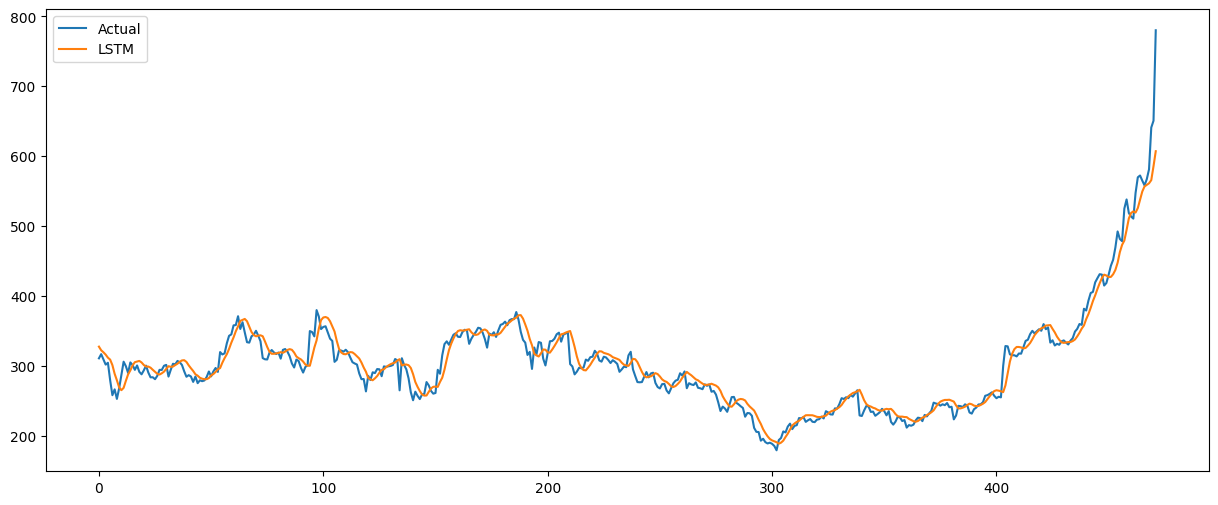

In [32]:
plt.figure(figsize=(15,6))

plt.plot(actual,label='Actual')

plt.plot(
scaler.inverse_transform(lstm_pred),
label='LSTM'
)

plt.legend()
plt.show()

## 16: 5 Day Prediction

### 16.1: Function:

In [33]:
future_input=X_test[-1]

future_predictions=[]

### 16.2: Loop:

In [34]:
for i in range(5):

    pred=model_lstm.predict(
    future_input.reshape(1,60,1)
    )

    future_predictions.append(pred[0][0])

    future_input=np.append(
    future_input[1:],
    pred
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


### 16.3: 10 Day Prediction

### 16.3.1: Same loop

In [35]:
range(10)

range(0, 10)

## 17: Hyperparameter Tuning

### 17.1: GridSearch (Parameters):

In [36]:
units=[32,50,100]

dropout=[0.1,0.2,0.3]

learning_rate=[0.001,0.01]

In [37]:
!pip install keras-tuner

In [38]:
import keras_tuner as kt

from keras_tuner import RandomSearch

In [39]:
import keras_tuner as kt

print(kt.__version__)

1.4.8


In [40]:
import keras_tuner as kt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [41]:
def build_model(hp):

    model = Sequential()

    model.add(
        LSTM(
            units=hp.Int(
                'units',
                min_value=32,
                max_value=128,
                step=32
            ),
            input_shape=(X_train.shape[1],1)
        )
    )

    model.add(
        Dropout(
            hp.Float(
                'dropout',
                min_value=0.1,
                max_value=0.5,
                step=0.1
            )
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice(
                'learning_rate',
                values=[0.001,0.01]
            )
        ),
        loss='mse'
    )

    return model

In [42]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    directory='tesla_tuning',
    project_name='lstm'
)

Reloading Tuner from tesla_tuning/lstm/tuner0.json


In [43]:
tuner.search(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

In [44]:
best_hp = tuner.get_best_hyperparameters()[0]

print("Units:", best_hp.get('units'))
print("Dropout:", best_hp.get('dropout'))
print("Learning Rate:", best_hp.get('learning_rate'))

Units: 64
Dropout: 0.5
Learning Rate: 0.001


In [45]:
best_model = tuner.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [46]:
pred = best_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


Keras Tuner Random Search was used to optimize the number of LSTM units, dropout rate, and learning rate. The best-performing hyperparameters were selected based on validation loss.

## 18: Streamlit App

In [47]:
!pip install streamlit pyngrok

In [52]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

st.title("Tesla Stock Price Prediction")

# Load Model
model = load_model(
    "lstm_model.h5",
    compile=False
)

st.success("Model Loaded Successfully")

# Load Dataset
df = pd.read_csv("TSLA.csv")

st.subheader("Tesla Dataset")

st.dataframe(df.tail())

# Close Price Graph
st.subheader("Tesla Closing Price Trend")

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(df["Close"])

ax.set_xlabel("Days")
ax.set_ylabel("Close Price")

st.pyplot(fig)

# Scaling
close_price = df[['Close']]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(close_price)

window = 60

X = []

for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i,0])

X = np.array(X)

X = X.reshape(X.shape[0], X.shape[1], 1)

# Prediction
predictions = model.predict(X)

predictions = scaler.inverse_transform(predictions)

actual = close_price.iloc[window:].values

# Actual vs Predicted
st.subheader("Actual vs Predicted")

fig2, ax2 = plt.subplots(figsize=(10,5))

ax2.plot(actual, label="Actual")

ax2.plot(predictions, label="Predicted")

ax2.legend()

st.pyplot(fig2)

# Future 5 Days Prediction
st.subheader("Next 5 Days Prediction")

future_input = scaled_data[-60:]

future_predictions = []

for i in range(5):

    pred = model.predict(
        future_input.reshape(1,60,1),
        verbose=0
    )

    future_predictions.append(pred[0][0])

    future_input = np.append(
        future_input[1:],
        pred
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

st.write("Next 5 Day Predicted Prices")

for i, price in enumerate(future_predictions):

    st.write(
        f"Day {i+1}: ${price[0]:.2f}"
    )

Overwriting app.py


In [53]:
!ls

app.py	lstm_model.h5  sample_data  tesla_tuning  TSLA.csv


In [54]:
!pkill -f streamlit

In [55]:
from pyngrok import ngrok

!ngrok config add-authtoken 3AA7y9Jm6dmEWbJ9bmMq4l7bxRk_81w9aTM2acuCxeakVrZkz

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [56]:
from pyngrok import ngrok

!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)

public_url

<NgrokTunnel: "https://darien-unconducive-aiyana.ngrok-free.dev" -> "http://localhost:8501">

## 19: Streamlit Application Output

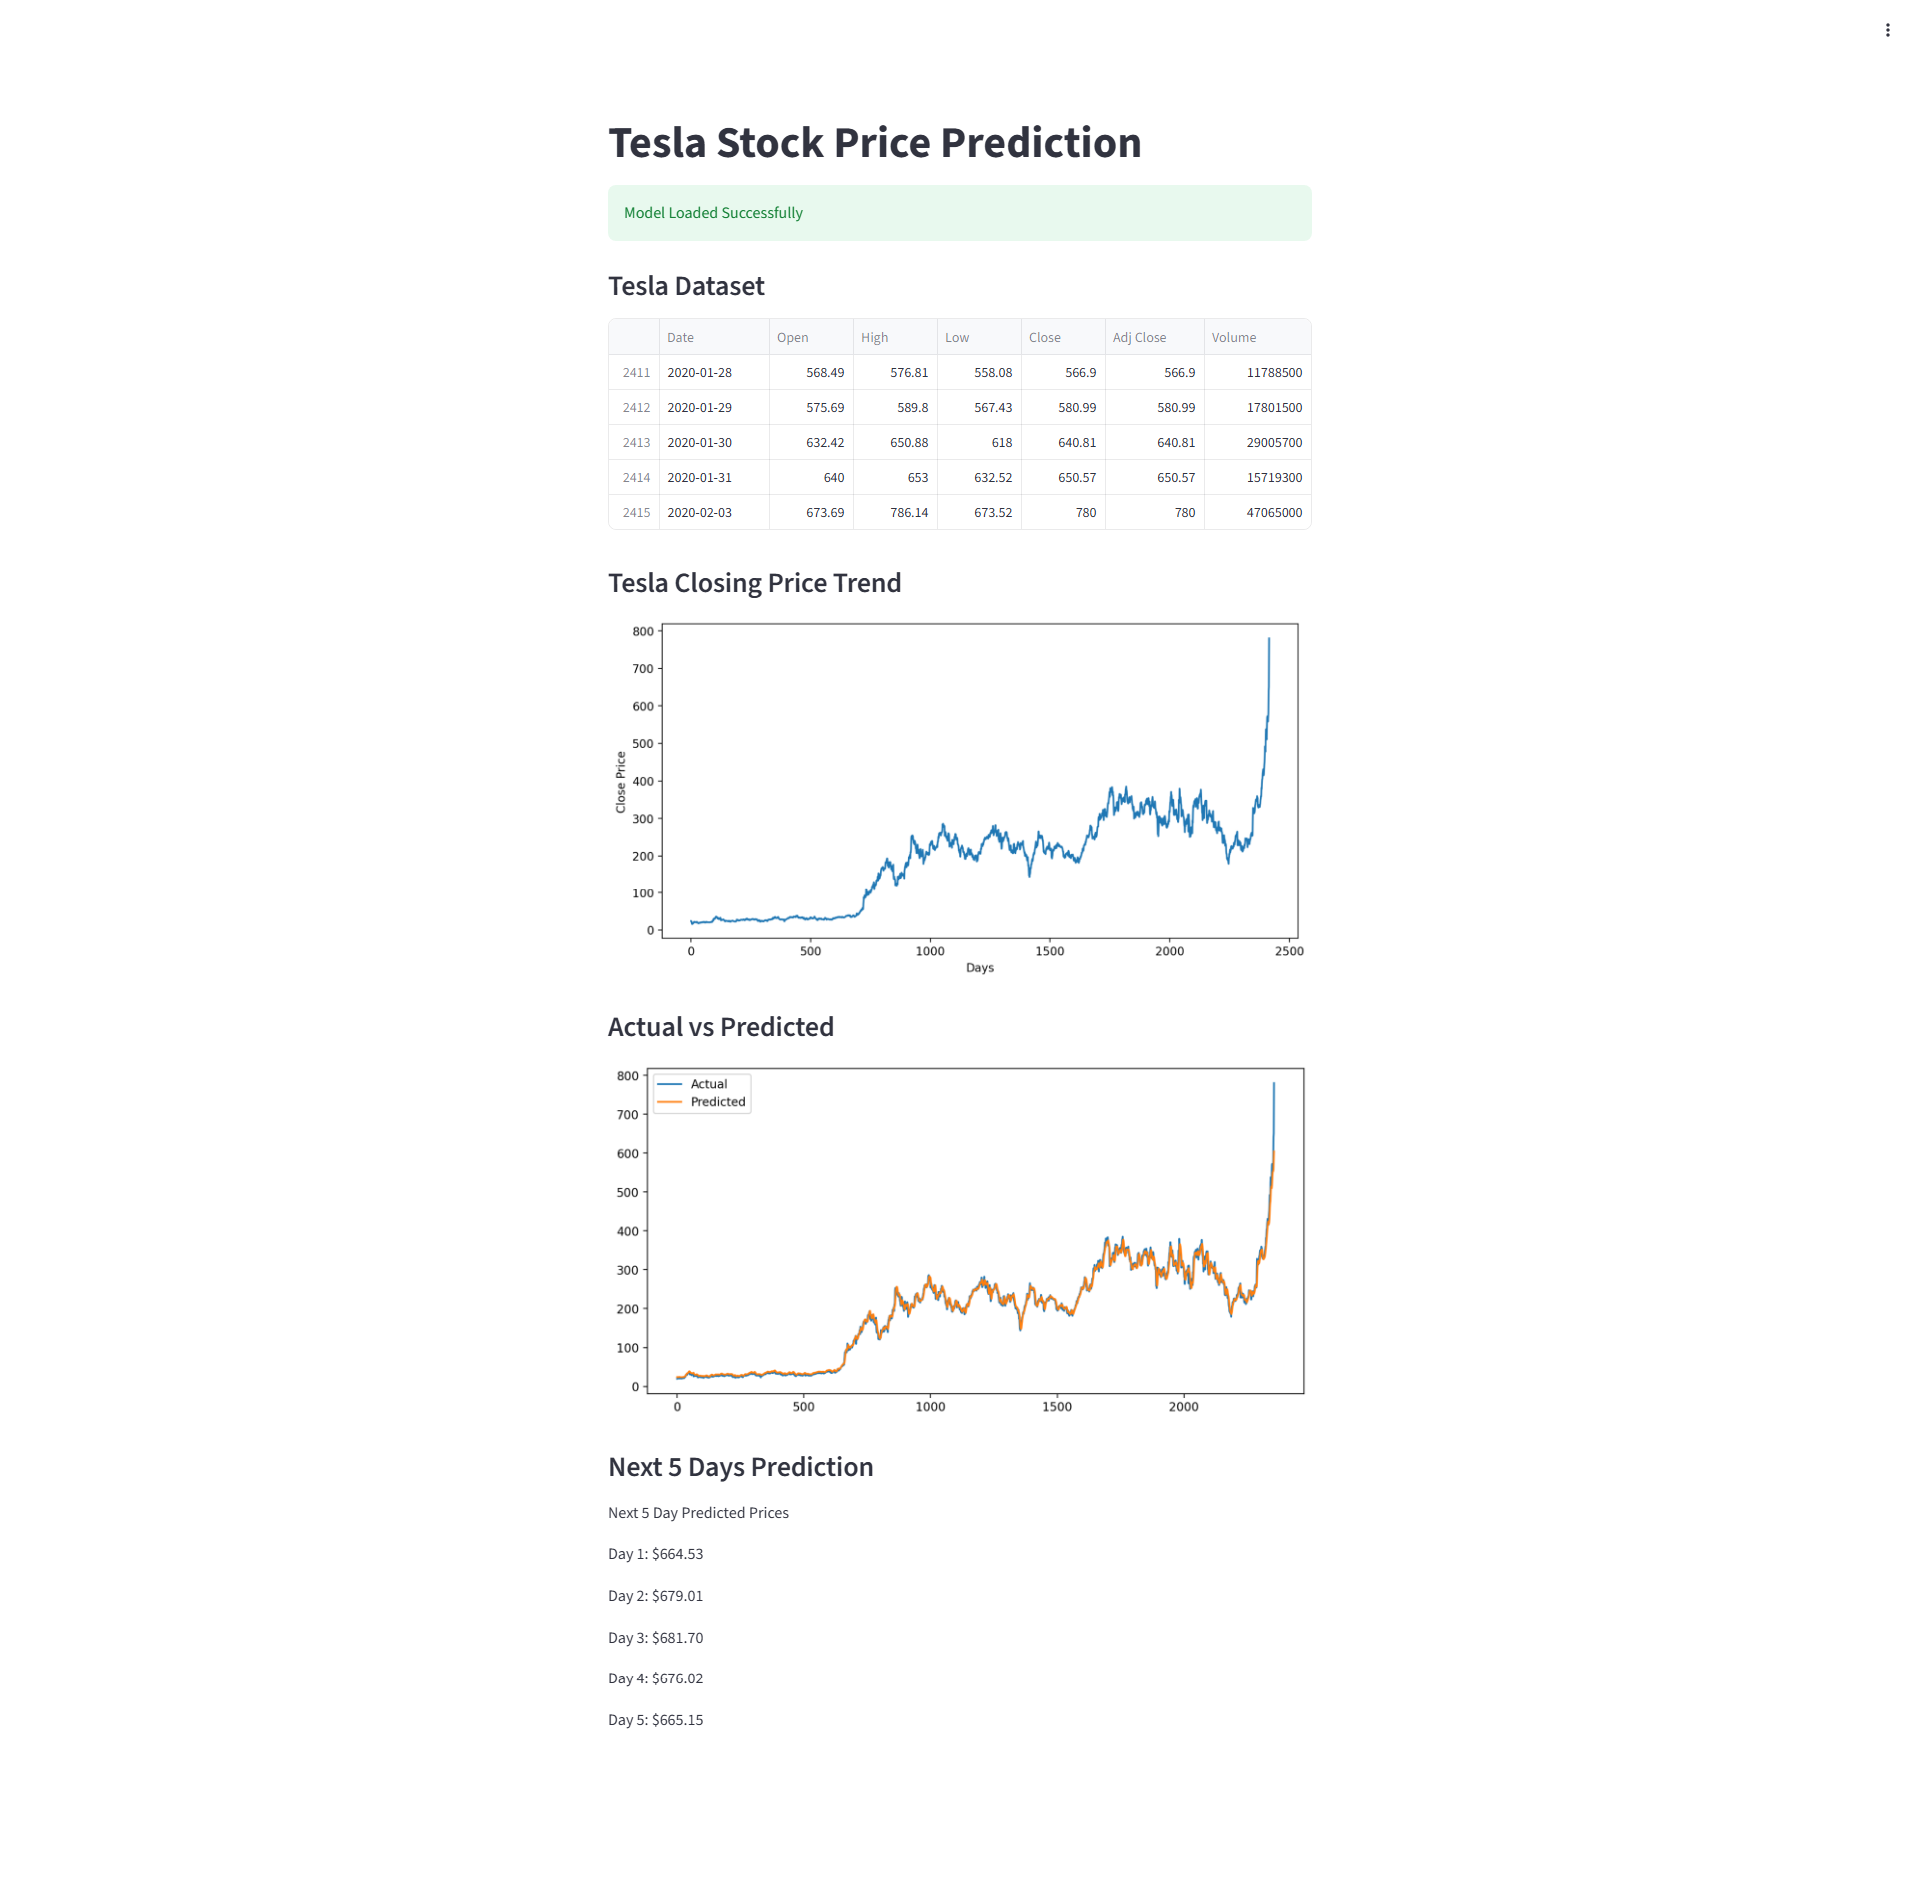

## 20: Conclusion

This project successfully developed and compared SimpleRNN and LSTM models for Tesla stock price prediction using historical stock market data. The dataset was preprocessed, scaled, and converted into time-series sequences before training the models.

The performance of both models was evaluated using Mean Squared Error (MSE), and the results showed that the LSTM model performed better than the SimpleRNN model due to its ability to capture long-term dependencies in sequential data. Hyperparameter tuning using Keras Tuner further improved the model's performance by selecting the optimal number of units, dropout rate, and learning rate.

A Streamlit-based web application was also developed to visualize stock price trends, compare actual and predicted prices, and generate future stock price predictions. Overall, the project demonstrates the effectiveness of deep learning techniques for stock market forecasting.

## 21: Future Improvements

21.1: Use More Features

Include:
- Open Price
- High Price
- Low Price
- Volume

Technical Indicators:
- RSI
- MACD
- Moving Averages

This can improve prediction accuracy.

21.2: Advanced Deep Learning Models

Implement:
- Bidirectional LSTM
- GRU (Gated Recurrent Unit)
- Transformer Models
- Attention Mechanisms

These models may capture market patterns more effectively.

21.3: Real-Time Data Integration

Use APIs such as:
- Yahoo Finance API
- Alpha Vantage API

This will enable real-time stock prediction.

21.4: Long-Term Forecasting

Extend prediction horizon to:
- 30 Days
- 60 Days
- 90 Days

Instead of only short-term forecasting.

21.5: Model Optimization

Apply:
- Advanced Hyperparameter Tuning
- Ensemble Learning Techniques

To further improve model performance.

21.6: Deployment

Deploy the application on:
- Streamlit Cloud
- AWS
- Microsoft Azure
- Google Cloud Platform

For public access and scalability.

21.7: Sentiment Analysis

Incorporate:
- Financial News Analysis
- Social Media Sentiment Analysis

To improve forecasting accuracy.

21.8: Risk Analysis

Add:
- Investment Risk Analysis
- Buy/Sell Recommendations
- Portfolio Support Features

To assist investors in decision-making.